In [1]:
!pip install shap

In [1]:
import pandas as pd
import numpy as np

import shap
import joblib

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv(
    "../data/customer_churn.csv"
)

df.head()

,frequency,monetary,avg_order_value,category_count,avg_review_score,avg_delivery_days,total_freight_paid,recency_days,customer_tenure_days,cluster,customer_segment,clv,churn,customer_segment_encoded
0,1,141.90,141.90,1,5.0,6.0,12.00,115,115,2,Active Customers,44.708219,0,0
1,1,27.19,27.19,1,4.0,3.0,8.29,118,118,2,Active Customers,8.790192,0,0
2,1,86.22,86.22,1,3.0,25.0,17.22,541,541,0,Inactive Customers,127.794575,1,2
3,1,43.62,43.62,1,4.0,20.0,17.63,325,325,0,Inactive Customers,38.839726,0,2
4,1,196.89,196.89,1,5.0,13.0,16.89,292,292,0,Inactive Customers,157.512000,0,2


In [3]:
churn_threshold = df["recency_days"].quantile(
    0.75
)

df["churn"] = (
    df["recency_days"] > churn_threshold
).astype(int)

In [4]:
df["monetary_log"] = np.log1p(
    df["monetary"]
)

In [5]:
churn_features = [
    "customer_segment_encoded",
    "frequency",
    "monetary",
    "avg_order_value",
    "category_count",
    "avg_review_score",
    "avg_delivery_days",
    "total_freight_paid"
]

X_churn = df[churn_features]

y_churn = df["churn"]

In [5]:
spend_features = [
    "frequency",
    "avg_order_value",
    "category_count",
    "avg_review_score",
    "avg_delivery_days",
    "total_freight_paid",
    "customer_segment_encoded"
]

X_spend = df[spend_features]

y_spend = df["monetary_log"]

In [7]:
X_train_churn, X_test_churn, y_train_churn, y_test_churn = train_test_split(
    X_churn,
    y_churn,
    test_size=0.2,
    random_state=42,
    stratify=y_churn
)

In [6]:
X_train_spend, X_test_spend, y_train_spend, y_test_spend = train_test_split(
    X_spend,
    y_spend,
    test_size=0.2,
    random_state=42
)

In [9]:
xgb_churn = joblib.load(
    "../models/churn_xgboost.pkl"
)

rf_spend = joblib.load(
    "../models/spend_prediction_rf.pkl"
)

### CHURN SHAP

In [10]:
explainer_churn = shap.TreeExplainer(
    xgb_churn
)

In [11]:
sample_churn = X_test_churn.sample(
    1000,
    random_state=42
)

In [12]:
shap_values_churn = explainer_churn.shap_values(
    sample_churn
)

In [13]:
print(X_churn.columns.tolist())

['customer_segment_encoded', 'frequency', 'monetary', 'avg_order_value', 'category_count', 'avg_review_score', 'avg_delivery_days', 'total_freight_paid']


In [14]:
print(type(xgb_churn))

<class 'xgboost.sklearn.XGBClassifier'>


In [15]:
importance_check = pd.DataFrame({
    "Feature": X_churn.columns,
    "Importance": xgb_churn.feature_importances_
})

importance_check = importance_check.sort_values(
    "Importance",
    ascending=False
)

importance_check

,Feature,Importance
0,customer_segment_encoded,0.915096
5,avg_review_score,0.043714
7,total_freight_paid,0.010358
4,category_count,0.008370
6,avg_delivery_days,0.007246
2,monetary,0.006063
3,avg_order_value,0.005874
1,frequency,0.003280


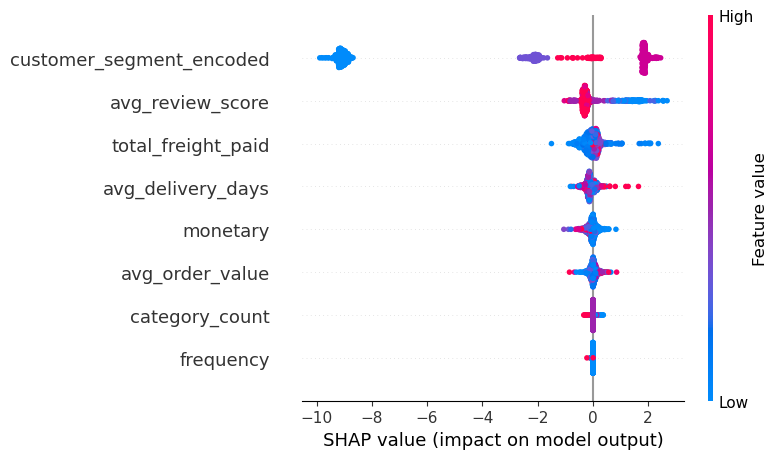

In [16]:
shap.summary_plot(
    shap_values_churn,
    sample_churn,
    show=False
)

plt.tight_layout()

plt.savefig(
    "../visualizations/shap_summary_churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

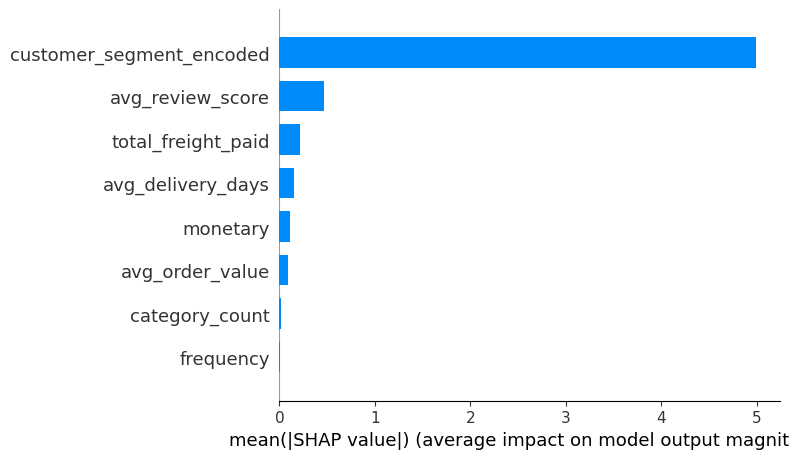

In [17]:
shap.summary_plot(
    shap_values_churn,
    sample_churn,
    plot_type="bar",
    show=False
)

plt.tight_layout()

plt.savefig(
    "../visualizations/shap_bar_churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
customer_churn = sample_churn.iloc[[0]]

single_shap_churn = explainer_churn.shap_values(
    customer_churn
)

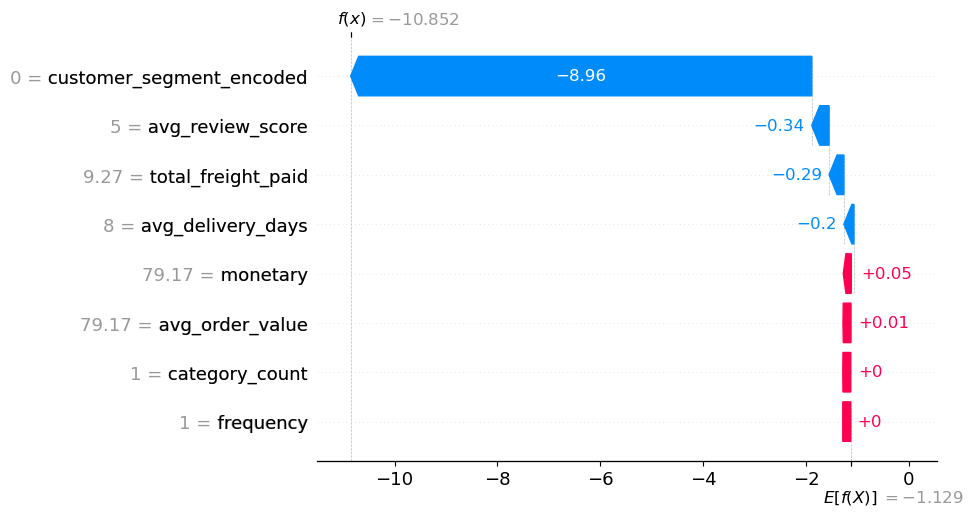

In [19]:
shap.plots.waterfall(
    shap.Explanation(
        values=single_shap_churn[0],
        base_values=explainer_churn.expected_value,
        data=customer_churn.iloc[0],
        feature_names=customer_churn.columns
    ),
    show=False
)

plt.savefig(
    "../visualizations/shap_waterfall_churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### SPEND PREDICTION SHAP

In [20]:
importance_check = pd.DataFrame({
    "Feature": X_spend.columns,
    "Importance": rf_spend.feature_importances_
})

importance_check.sort_values(
    "Importance",
    ascending=False
)

,Feature,Importance
1,avg_order_value,0.867505
5,total_freight_paid,0.070639
6,customer_segment_encoded,0.040076
4,avg_delivery_days,0.012558
3,avg_review_score,0.004149
2,category_count,0.002722
0,frequency,0.002351


In [ ]:
# import shap

# explainer_spend = shap.TreeExplainer(
#     rf_spend
# )

In [ ]:
# sample_spend = X_spend.sample(
#     1000,
#     random_state=42
# )

In [7]:
xgb_spend = joblib.load(
    "../models/spend_prediction_xgb.pkl"
)

explainer_spend = shap.TreeExplainer(
    xgb_spend
)

sample_spend = X_spend.sample(
    200,
    random_state=42
)

shap_values_spend = explainer_spend.shap_values(
    sample_spend
)

In [8]:
print(type(shap_values_spend))

if hasattr(shap_values_spend, "shape"):
    print(shap_values_spend.shape)

<class 'numpy.ndarray'>
(200, 7)


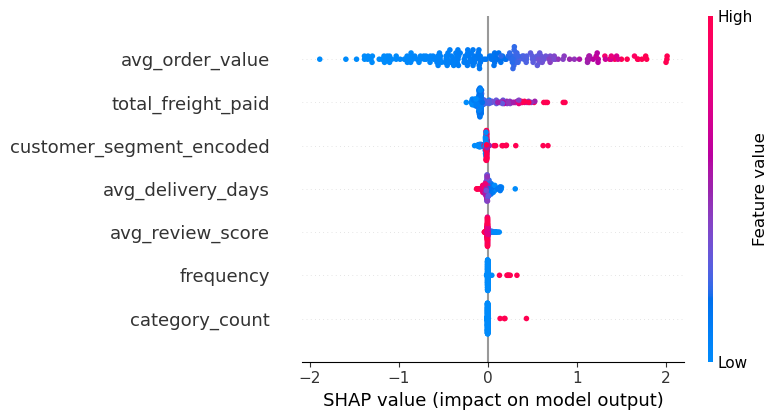

In [9]:
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values_spend,
    sample_spend,
    show=False
)

plt.tight_layout()

plt.savefig(
    "../visualizations/shap_summary_spend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

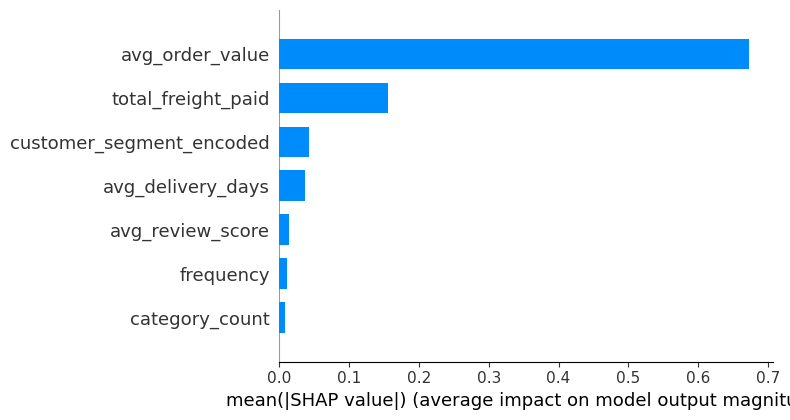

In [10]:
shap.summary_plot(
    shap_values_spend,
    sample_spend,
    plot_type="bar",
    show=False
)

plt.tight_layout()

plt.savefig(
    "../visualizations/shap_bar_spend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:
customer_spend = sample_spend.iloc[[0]]

single_shap_spend = explainer_spend.shap_values(
    customer_spend
)

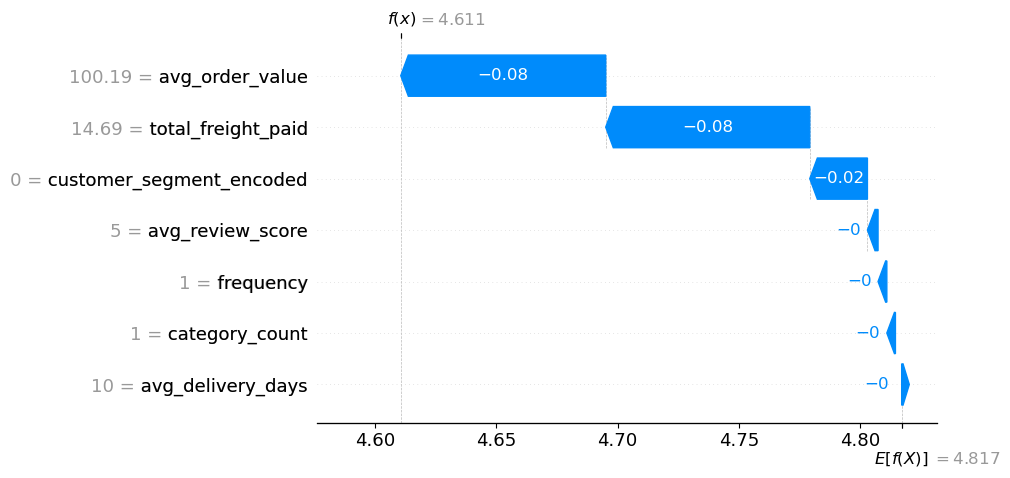

In [12]:
shap.plots.waterfall(
    shap.Explanation(
        values=single_shap_spend[0],
        base_values=explainer_spend.expected_value,
        data=customer_spend.iloc[0],
        feature_names=customer_spend.columns
    ),
    show=False
)

plt.savefig(
    "../visualizations/shap_waterfall_spend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [2]:
import pandas as pd
df = pd.read_csv(
    "../data/customer_features_v2.csv"
)

print(df.columns.tolist())

['customer_unique_id', 'frequency', 'monetary', 'avg_order_value', 'last_purchase', 'first_purchase', 'category_count', 'avg_review_score', 'avg_delivery_days', 'total_freight_paid', 'recency_days', 'customer_tenure_days']
